In [45]:
pip install --upgrade datasets

In [46]:
token = "hf_REDACTED"
from huggingface_hub import login
login(token)

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "google/gemma-2-2b-it"
tokenizer = AutoTokenizer.from_pretrained(model_id, token=token)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", torch_dtype=torch.float16)


tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

In [4]:
# ===== ONE-TIME SETUP (run once) =====
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

# Optional: remove unused sampling params stored in generation_config
model.generation_config.top_k = None
model.generation_config.top_p = None
model.generation_config.do_sample = False




```
# This is formatted as code
```

<h1><b>Sentiment Analysis</b></h1>

---
Dataset : IMDB ,
Totall Samples : 1000

In [5]:
def batch_zero_shot_prompt(review):
    return f"""You are a sentiment analysis expert.

Review: "{review[0]}"

What is the sentiment of movie review above.Choose only one of the following:
- Positive
- Negative

Respond with one word only:

Answer:"""

In [6]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Positive|Negative)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [7]:
from datasets import load_dataset

# Load the IMDb test subset
dataset = load_dataset("imdb", split="test")
shuffled_dataset = dataset.shuffle(seed=42)

Samples = shuffled_dataset.select(range(1000))

# IMDb labels: 0 = negative, 1 = positive
label_counts = {"positive": 0, "negative": 0}

# Count positive and negative labels
for example in Samples:
    label = example["label"]
    if label == 1:
        label_counts["positive"] += 1
    else:
        label_counts["negative"] += 1

print("Total reviews:", len(dataset))
print("Positive reviews:", label_counts["positive"])
print("Negative reviews:", label_counts["negative"])


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Total reviews: 25000
Positive reviews: 488
Negative reviews: 512


In [8]:
texts = []
true_labels = []
for i in range (0,len(Samples['text'])):
    texts.append(Samples['text'][i])
for i in range (0,len(Samples['text'])):
    true_labels.append(Samples['label'][i])
print(Samples)
print(len(texts))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
1000
1000


In [9]:
pip install codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.7/358.7 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 12.1 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.27.2 which is incompatible.
google-genai 1.55.0 requi

In [10]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name="gemma-2-2b-it",
    output_dir=".",          # where the CSV will be saved
    tracking_mode="process", # tracks CPU/GPU for this process only
    measure_power_secs=5,
    log_level="error"
)


[codecarbon WARNING @ 13:12:46] Multiple instances of codecarbon are allowed to run at the same time.


In [11]:
batch_size = 1
predicted_labels = []

# IMPORTANT FIXES
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

tracker.start()

for i in range(0, len(Samples), batch_size):
    batch = Samples[i:i+batch_size]["text"]

    prompt = batch_zero_shot_prompt(batch)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    prediction = extract_sentiment(decoded)

    print("\nMODEL OUTPUT:\n", decoded)
    print("PREDICTION:", prediction)
    print("=" * 60)

    predicted_labels.append(prediction)

emissions = tracker.stop()



Streaming output truncated to the last 5000 lines.

MODEL OUTPUT:
 You are a sentiment analysis expert.

Review: "We sought out this hard-to-find VHS after watching two excellent Merchant-Ivory pictures back to back. Knowing it was an instant box office failure, a failure as a rental, I thought it might be worth seeing anyway based on M-I's reputation. Too bad! Nine years ago, it was very much a Liberal Agenda objective to trash the Founding Fathers and indeed they had some success in eradicating the Founding Fathers from many American classrooms including, for example, New Jersey; whose eradication of our great founders quickly ended when the Washington Times shone the spotlight of truth into the NJ School Board and their subversive deed. A small part of this was headlining the alleged Sally Hemmings-Thomas Jefferson connection, disregarding the inconvenient DNA findings which failed to support the wacky left's agenda. Never mind! They got James Ellis, an author of dubious reputation,

In [12]:
# --- one-time fixes ---
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

# Optional: silence invalid top_k/top_p warnings
model.generation_config.top_k = None
model.generation_config.top_p = None
model.generation_config.do_sample = False

# --- inference ---
inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
).to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

decoded = tokenizer.decode(output[0], skip_special_tokens=True)
print(decoded)


You are a sentiment analysis expert.

Review: "This is the best version of Gypsy that has been filmed.Bette Midler is simply superb as Mama Rose.She has the voice,the gestures,the look,and most of all,a supreme acting ability to carry the role off and to make her character come alive.Her singing is,simply put:MAGNIFICENT! She especially shines in two numbers-"Everything's Coming Up Roses" and "Rose's Turn". The other actors are also fine,particularly Christine Ebersoll as Tessie.Also good is Peter Riegert;his portrayal of Herbie is acted with great style and believability.The direction of this movie is very,very good.There isn't a false note or gaffe in the entire production.This film is a vast improvement over the Roz Russell version filmed in 1962.Since viewing it again,I can state that the three greatest Mama Roses are:Ethel Merman,Bette Midler,and Angela Lansbury. See this movie.You'll be glad that you did."

What is the sentiment of movie review above.Choose only one of the follow

In [13]:
# Map predictions to 0/1
predictions = [1 if s == "Positive" else 0 for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)



Accuracy: 0.88
F1 Score: 0.8657718120805369
Recall: 0.7930327868852459
Precision: 0.9532019704433498


In [14]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 1000
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : gemma-2-2b-it
Duration (s)           : 361.69

--- Energy ---
Total energy (kWh)     : 0.011590
Energy per sample (J)  : 41.72
Energy per 1k samples (kJ): 0.04

--- Carbon ---
CO₂ emissions (kg)     : 0.000046
CO₂ per sample (g)     : 0.0000

--- Time ---
Avg time per sample (s): 0.362

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.00GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : Canada
Cloud provider         : nan
Tracking mode          : process




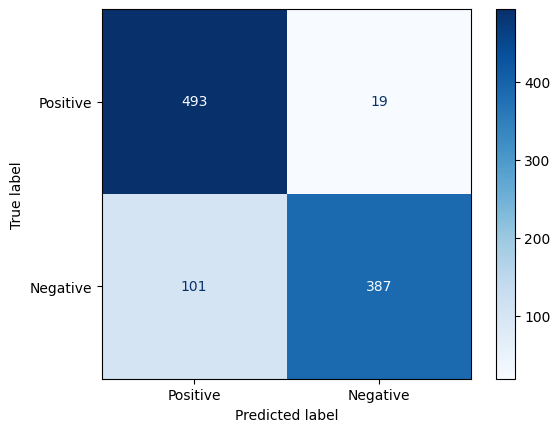

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

<h1><b>Hate Speech Detection</b></h1>

---
Dataset : OLID ,
Totall Samples : 400



In [16]:
from datasets import load_dataset

dataset = load_dataset("christophsonntag/OLID", split="test")
dataset[5]


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/13240 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/860 [00:00<?, ? examples/s]

{'id': 83681,
 'tweet': '. . . What the fuck did he do this time?',
 'cleaned_tweet': 'fuck time',
 'subtask_a': 'OFF',
 'subtask_b': 'TIN',
 'subtask_c': 'IND'}

In [17]:
dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 860
})

In [18]:
shuffled_dataset = dataset.shuffle(seed=42).select(range(800))

shuffled_dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 800
})

In [19]:
negatives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'OFF').select(range(200))
positives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'NOT').select(range(200))

# Combine both subsets
from datasets import concatenate_datasets
Samples = concatenate_datasets([negatives, positives])

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

In [20]:
Samples = Samples.shuffle()

In [21]:
label_counts = {"OFF": 0, "NOT": 0}

# Count positive and negative labels
for example in Samples:
    label = example["subtask_a"]
    if label == 'OFF':
        label_counts["OFF"] += 1
    else:
        label_counts["NOT"] += 1

print("Total tweets:", len(Samples))
print("Offensive tweets:", label_counts["OFF"])
print("Non-offensive tweets:", label_counts["NOT"])

Total tweets: 400
Offensive tweets: 200
Non-offensive tweets: 200


In [22]:
tweets = []
true_labels = []
for i in range (0,len(Samples['tweet'])):
    tweets.append(Samples['cleaned_tweet'][i])
for i in range (0,len(Samples['tweet'])):
    true_labels.append(Samples['subtask_a'][i])
print(Samples)
print(len(tweets))
print(len(true_labels))

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 400
})
400
400


In [23]:
tweets[0]

'denver venues stacked epic shows fall put together fall music guide help pick shows going hit season check'

In [24]:
def batch_zero_shot_prompt(review):
    return f"""Read this tweet below :

Tweet: "{review[0]}"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
"""


In [25]:
import re
def extract_detection(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Offensive|Non-offensive)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [26]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples["tweet"]), batch_size):
    batch = Samples[i:i+batch_size]["tweet"]

    prompt = batch_zero_shot_prompt(batch)   # your hate prompt function

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)

    # print to see output (debug)
    print("\nOUTPUT:\n", decoded)
    print("-" * 60)

    prediction = extract_detection(decoded)
    predicted_labels.append(prediction)


Streaming output truncated to the last 5000 lines.
 Read this tweet below :

Tweet: "2 weeks of resp done and I still don't know shit my ass still on vacation mode 😪"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
Offensive 

------------------------------------------------------------

OUTPUT:
 Read this tweet below :

Tweet: "#GreatAwakening  #QAnon #Resist #ImpeachTrump #Mueller #MuellerTime  liberals who liked/retweeted my post and don't know what exculpatory" means. lol. It's a testament to their lack of interest in details.  Thanks guys!! URL"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
Offensive 

------------------------------------------------------------

OUTPUT:
 Read this tweet below :

Tweet: "#1 Nick Gehlfuss stan just watched Friends! and she is not going to stop #tvtime URL"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
Non-off

In [27]:
# Map predictions to 0/1
predictions = [1 if s == "Offensive" else 0 for s in predicted_labels]
actual = [1 if s == 'OFF' else 0 for s in true_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(actual, predictions)
f1 = f1_score(actual, predictions)
recall = recall_score(actual, predictions)
precision = precision_score(actual, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.7025
F1 Score: 0.7586206896551724
Recall: 0.935
Precision: 0.6382252559726962


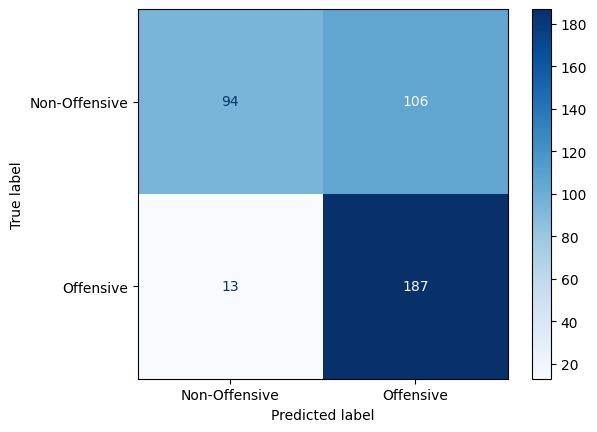

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(actual, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Offensive", "Offensive"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [29]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 400
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : gemma-2-2b-it
Duration (s)           : 361.69

--- Energy ---
Total energy (kWh)     : 0.011590
Energy per sample (J)  : 104.31
Energy per 1k samples (kJ): 0.10

--- Carbon ---
CO₂ emissions (kg)     : 0.000046
CO₂ per sample (g)     : 0.0001

--- Time ---
Avg time per sample (s): 0.904

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.00GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : Canada
Cloud provider         : nan
Tracking mode          : process




<h1><b>News Classification</b></h1>

---



In [30]:
from datasets import load_dataset
print("=== AG News ===")
ag_news = load_dataset("ag_news", split="test")
ag_news

=== AG News ===


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})

In [31]:
ag_news.features['label']

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])

In [32]:
ag_news[4]

{'text': "Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fighting agency went after emissions of the bovine variety Friday, adopting the nation's first rules to reduce air pollution from dairy cow manure.",
 'label': 3}

In [33]:
World = ag_news.filter(lambda x: x['label'] == 0).select(range(150))
Sports = ag_news.filter(lambda x: x['label'] == 1).select(range(150))
Business = ag_news.filter(lambda x: x['label'] == 2).select(range(150))
SciTech = ag_news.filter(lambda x: x['label'] == 3).select(range(150))

from datasets import concatenate_datasets
Samples = concatenate_datasets([World, Sports,Business,  SciTech])

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [34]:
Samples[42]

{'text': 'Israelis OK new homes in West Bank A leaked Israeli plan to build 1,000 new Jewish settler homes in the West Bank yesterday sent Bush administration officials scrambling for a response in the sensitive period before November #39;s presidential election. ',
 'label': 0}

In [35]:
Samples = Samples.shuffle()

In [36]:
label_counts = {"World":0, "Sports": 0, "Business" :0, "Sci/Tech": 0}

# Count labels
for example in Samples:
    label = example["label"]
    if label == 0:
        label_counts["World"] += 1
    elif label == 1:
        label_counts["Sports"] += 1
    elif label == 2:
        label_counts["Business"] += 1
    else:
        label_counts["Sci/Tech"] += 1

print("Total :", len(Samples))
print("World:", label_counts["World"])
print("Sports:", label_counts["Sports"])
print("Business:", label_counts["Business"])
print("Sci/Tech", label_counts["Sci/Tech"])

Total : 600
World: 150
Sports: 150
Business: 150
Sci/Tech 150


In [37]:
news = []
true_labels = []
for example in Samples:
    emotion = example["text"]
    label = example["label"]
    news.append(emotion)
    true_labels.append(label)

print(Samples)
print(len(news))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 600
})
600
600


In [38]:
print(Samples[300])
print(news[300])
print(true_labels[300])

{'text': 'Microsoft offers SP2 compatibility guide Security-focused Windows XP update can be tough on applications. Guidelines are meant to help professionals "test and mitigate."', 'label': 3}
Microsoft offers SP2 compatibility guide Security-focused Windows XP update can be tough on applications. Guidelines are meant to help professionals "test and mitigate."
3


In [39]:
def news_classification_prompt(article):
    return f"""You are an AI assistant trained to classify news articles based on their content.

Article: "{article[0]}"

Classify the article into one of the following categories:
- World
- Sports
- Business
- SciTech

Answer in one word only.

Answer:"""

In [40]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(World|Sports|Business|SciTech)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [41]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples), batch_size):
    batch = Samples[i:i+batch_size]["text"]

    prompt = news_classification_prompt(batch)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)

    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

print(predicted_labels[:20])


['Scitech', 'World', 'Business', 'World', 'Business', 'Sports', 'Scitech', 'World', 'Business', 'Sports', 'World', 'Scitech', 'World', 'Scitech', 'Scitech', 'Scitech', 'Business', 'World', 'Sports', 'Sports']


In [42]:
# Map predictions to 0/1
label_map = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Scitech": 3
}

predictions = [label_map[s] for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions, average='macro')
recall = recall_score(true_labels, predictions, average='macro')
precision = precision_score(true_labels, predictions, average='macro')

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.7916666666666666
F1 Score: 0.7841451961330289
Recall: 0.7916666666666666
Precision: 0.8204653681580085


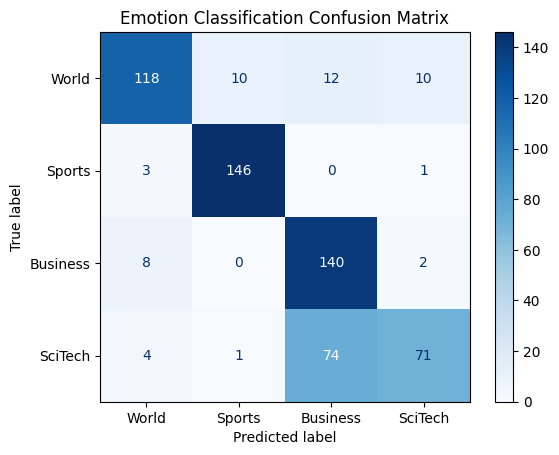

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World","Sports", "Business","SciTech"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Emotion Classification Confusion Matrix")
plt.show()

In [44]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 1000
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : gemma-2-2b-it
Duration (s)           : 361.69

--- Energy ---
Total energy (kWh)     : 0.011590
Energy per sample (J)  : 41.72
Energy per 1k samples (kJ): 0.04

--- Carbon ---
CO₂ emissions (kg)     : 0.000046
CO₂ per sample (g)     : 0.0000

--- Time ---
Avg time per sample (s): 0.362

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.00GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : Canada
Cloud provider         : nan
Tracking mode          : process


